In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata
import gseapy
from scipy.stats import median_abs_deviation
import seaborn as sns
import math
from scipy.stats import binom

In [ ]:
adata = anndata.read_h5ad('HK177_02_processed.h5ad')


In [3]:
def load_arial(arial_folder_path):
    from pathlib import Path
    from matplotlib import font_manager, rcParams
    for font_path in Path(arial_folder_path).glob('*.TTF'):
        font_manager.fontManager.addfont(str(font_path))

    arial_n = {'fontproperties':font_manager.FontProperties(fname="misc/arial/ARIALN.TTF")}
    arial_nb = {'fontproperties':font_manager.FontProperties(fname="misc/arial/ARIALNB.TTF")}

    assert 'Arial' in [f.name for f in font_manager.fontManager.ttflist]

    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Arial']
    rcParams['ps.fonttype'] = 42
    rcParams['pdf.fonttype'] = 42

    rcParams['mathtext.fontset'] = 'custom'
    rcParams['mathtext.rm'] = 'Arial'
    rcParams['mathtext.it'] = 'Arial:italic'
    rcParams['mathtext.bf'] = 'Arial:bold'

    return arial_n, arial_nb
load_arial('/stor/home/tms4478/work/Arial')

({'fontproperties': <matplotlib.font_manager.FontProperties at 0x76e7fa523d60>},
 {'fontproperties': <matplotlib.font_manager.FontProperties at 0x76eab8ee2ef0>})

Remove ribosomal genes

In [4]:
print(adata.shape)
adata = adata[:, [not gene.startswith('RPL') and not gene.startswith('RPS') for gene in adata.var_names]]
print(adata.shape)

(3850, 15404)
(3850, 15310)


# Assign Migratory Lineages

Look through stiff gel and assign lineages that significantly increase or decrease as migratory or nonmigratory
Use a binomial distribution with a probability of 0.5

In [5]:
lineages = pd.DataFrame({'StiffMi': np.unique(adata.obs['lineage'][adata.obs['sample']=='StiffMi'], return_counts=True)[1]}, index=np.unique(adata.obs['lineage'][adata.obs['sample']=='StiffMi'], return_counts=True)[0])

In [6]:
for sample in ['StiffNon', 'SoftMi', 'SoftNon']:
    # print(pd.DataFrame({sample: np.unique(adata.obs['lineage'][adata.obs['sample']==sample], return_counts=True)[1]}, index=np.unique(adata.obs['lineage'][adata.obs['sample']==sample], return_counts=True)[0]))
    lineages = lineages.merge(pd.DataFrame({sample: np.unique(adata.obs['lineage'][adata.obs['sample']==sample], return_counts=True)[1]}, index=np.unique(adata.obs['lineage'][adata.obs['sample']==sample], return_counts=True)[0]), how='outer', left_index=True, right_index=True).fillna(0)

In [7]:
lineages['total'] = np.sum(lineages, axis=1)
lineages = lineages.sort_values(by='total', ascending=False)
lineages

,StiffMi,StiffNon,SoftMi,SoftNon,total
none,262.0,160.0,152.0,235.0,809.0
AATAGAGTAGGTCCAGCGTT,90.0,66.0,85.0,77.0,318.0
TGGCGAGCCGCTGCCACTAG,58.0,85.0,38.0,75.0,256.0
GTGAATTTCCTGGGGGATTG,71.0,42.0,57.0,58.0,228.0
CTTTATATCACGAGATAGAC,31.0,31.0,27.0,33.0,122.0
...,...,...,...,...,...
AGCGAGAGCGGCAGGCAGTG,1.0,0.0,0.0,0.0,1.0
TGGCTCCCGGTCATTAGCCC,0.0,0.0,1.0,0.0,1.0
TGGTGCTATAAGGGTAGGGA,0.0,1.0,0.0,0.0,1.0
TTAGTCCGGCCGTTAAGGTG,0.0,1.0,0.0,0.0,1.0


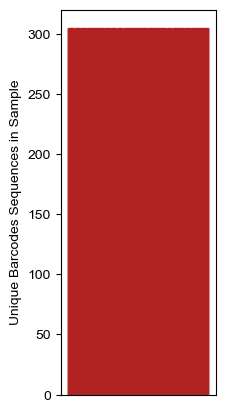

In [9]:
plt.subplots(figsize=(2, 5))
plt.bar(
    list(lineages.index),
    len(lineages),
    color='firebrick',
    edgecolor='firebrick',
    align='center'
    )
plt.ylabel('Unique Barcodes Sequences in Sample')
#plt.xlabel('Number of Unique Barcodes')
#plt.gca().invert_yaxis()
plt.xticks([]) 
#plt.savefig('NumberofBarcodes_scRNAseq.svg', bbox_inches='tight')
plt.show()

In [11]:
lineages = lineages[lineages.index != 'none']


In [12]:
lineages_prop = lineages/np.sum(lineages, axis=0)

In [14]:
lineage_p_vals = binom.pmf(lineages['StiffMi'], lineages['StiffMi']+lineages['StiffNon'], 0.5)
lineage_p_vals

array([1.01133047e-02, 5.22022976e-03, 1.79806745e-03, 1.00923686e-01,
       5.34055505e-03, 9.59616860e-02, 1.20190246e-02, 7.91510195e-02,
       9.74166393e-02, 2.06294060e-02, 4.68865037e-05, 1.68188095e-01,
       1.85470581e-01, 2.57302076e-02, 3.49121094e-02, 1.85470581e-01,
       1.85470581e-01, 3.26843262e-02, 2.09472656e-01, 1.81579590e-02,
       1.22192383e-01, 1.21398926e-01, 1.52740479e-01, 9.44213867e-02,
       2.09472656e-01, 2.46093750e-01, 1.20849609e-01, 1.20849609e-01,
       2.05078125e-01, 5.00000000e-01, 2.25585938e-01, 1.75781250e-02,
       2.73437500e-01, 1.61132813e-01, 2.73437500e-01, 2.34375000e-01,
       4.39453125e-02, 1.61132813e-01, 2.34375000e-01, 1.61132812e-02,
       1.17187500e-01, 3.12500000e-01, 1.56250000e-01, 2.18750000e-01,
       3.12500000e-02, 3.12500000e-01, 2.18750000e-01, 2.73437500e-01,
       2.73437500e-01, 9.37500000e-02, 1.56250000e-01, 2.73437500e-01,
       3.12500000e-01, 3.12500000e-01, 1.25000000e-01, 3.75000000e-01,
      

In [15]:
p_cutoff = 0.05

In [17]:
n = 20
x_axis_barcode = ['Barcode '+ str(n) for n in range(1,n+1)]
x_axis_barcode

['Barcode 1',
 'Barcode 2',
 'Barcode 3',
 'Barcode 4',
 'Barcode 5',
 'Barcode 6',
 'Barcode 7',
 'Barcode 8',
 'Barcode 9',
 'Barcode 10',
 'Barcode 11',
 'Barcode 12',
 'Barcode 13',
 'Barcode 14',
 'Barcode 15',
 'Barcode 16',
 'Barcode 17',
 'Barcode 18',
 'Barcode 19',
 'Barcode 20']

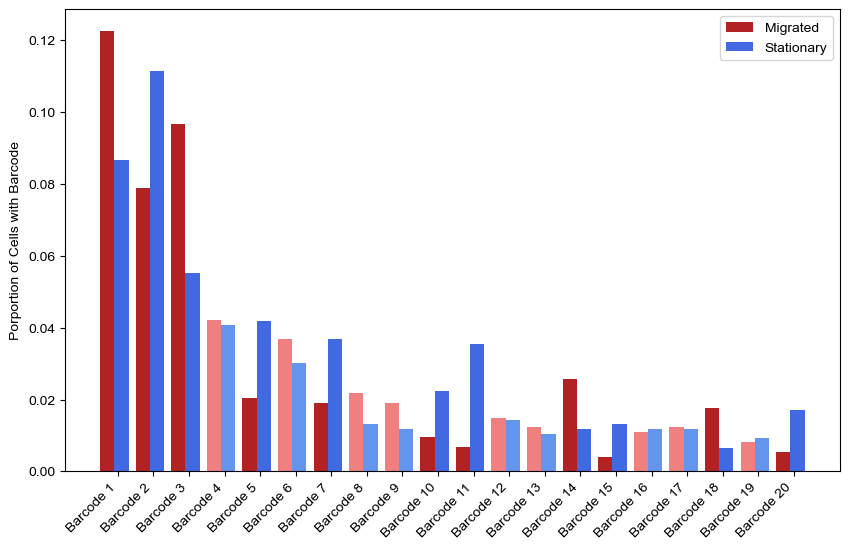

In [18]:
fig,ax = plt.subplots(figsize=(10,6))
n_bc_to_plot = 20
width = 0.4

ax.bar(np.arange(n_bc_to_plot), lineages_prop['StiffMi'][:n_bc_to_plot], width=width, label='Migrated', color=['firebrick' if p < p_cutoff else 'lightcoral' for p in lineage_p_vals])
ax.bar(np.arange(n_bc_to_plot)+0.4, lineages_prop['StiffNon'][:n_bc_to_plot], width=width, label='Stationary', color=['royalblue' if p < p_cutoff else 'cornflowerblue' for p in lineage_p_vals])

ax.set_xticks(np.arange(n_bc_to_plot)+0.3)
ax.set_xticklabels(lineages_prop.index[:n_bc_to_plot], rotation=45, ha='right')
ax.set_xticklabels(x_axis_barcode)
ax.set_ylabel('Porportion of Cells with Barcode')
ax.legend()

plt.savefig('MigratoryLineages.svg', bbox_inches='tight')
plt.show()

In [19]:
lineages.index

Index(['AATAGAGTAGGTCCAGCGTT', 'TGGCGAGCCGCTGCCACTAG', 'GTGAATTTCCTGGGGGATTG',
       'CTTTATATCACGAGATAGAC', 'AGGAGGGGTGCGGCGCCGTG', 'TGGCGTCAATGATGTAATCG',
       'ATACCATCCCTATGTCAACA', 'CAGCAATTTATACCATCCAA', 'TGACGTACCCCAGTCCAGGC',
       'ACTTTTACATCCAGCTTTAG',
       ...
       'TTTTTAAAATCTATCATTCA', 'ACCGTTGCCTGGCATGGCAA', 'ACGCGTAACACTAAGAGTGG',
       'ACTCTGAGCCACTGAGTGTT', 'AGCAATGTTATGACGATCGT', 'AGCGAGAGCGGCAGGCAGTG',
       'TGGCTCCCGGTCATTAGCCC', 'TGGTGCTATAAGGGTAGGGA', 'TTAGTCCGGCCGTTAAGGTG',
       'TTCAGGTGCCAGTTAGATGC'],
      dtype='object', length=304)

Set up the `sig_mig_lineage` obs - if a lineage is significant, call it by it's sequence, otherwise, put ''


In [21]:
lineage_phenotypes = {}
for lineage in lineages.index:
    mig_count = lineages.loc[lineage, 'StiffMi']
    non_count = lineages.loc[lineage, 'StiffNon']
    p = binom.pmf(mig_count, mig_count+non_count, 0.5)
    if p < p_cutoff:
        if mig_count > non_count:
            lineage_phenotypes[lineage] = 'migratory'
        else:
            lineage_phenotypes[lineage] = 'nonmigratory'

lineage_phenotypes

{'AATAGAGTAGGTCCAGCGTT': 'migratory',
 'TGGCGAGCCGCTGCCACTAG': 'nonmigratory',
 'GTGAATTTCCTGGGGGATTG': 'migratory',
 'AGGAGGGGTGCGGCGCCGTG': 'nonmigratory',
 'ATACCATCCCTATGTCAACA': 'nonmigratory',
 'ACTTTTACATCCAGCTTTAG': 'nonmigratory',
 'GGATAGGCGCTTTCTTCTGG': 'nonmigratory',
 'TTCCACATTCCCATAAGTCG': 'migratory',
 'TTTTAAGGTTCAGATTAATT': 'nonmigratory',
 'TAATCTCGCCCAAAAACTAC': 'migratory',
 'AATTGGACAATGTAAAGTAT': 'nonmigratory',
 'GAGAACTACACACGTACACA': 'nonmigratory',
 'TTCATGGCTAGTACGCTGAG': 'migratory',
 'GGTGGGGTCGGAGCTTGACT': 'nonmigratory',
 'GGTAGGAAGAGTGTTTTACG': 'nonmigratory'}

In [44]:
phenotype_obs = []

for lineage in adata.obs['lineage']:
    if lineage in lineage_phenotypes.keys():
        phenotype_obs.append(lineage_phenotypes[lineage])
    else:
        phenotype_obs.append('')

adata.obs['phenotype'] = phenotype_obs
adata.obs

/tmp/ipykernel_2726123/146763351.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phenotype'] = phenotype_obs


,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,...,predicted_doublets,lineage,S_score,G2M_score,phase,cc_difference,leiden_res0_25,leiden_res0_5,leiden_res1,phenotype
AAACCCACACGTAACT-1,SoftMi,4441,8.398860,18306.0,9.815039,20.135475,1302.0,7.172425,7.112422,3197.0,...,False,ATCTGGAAGTCGGGATGTGG,-0.030177,0.017713,G2M,-0.047890,1,2,6,
AAACGCTAGCACTAGG-1,SoftMi,5725,8.652772,32348.0,10.384338,18.903796,2894.0,7.970740,8.946458,8626.0,...,False,CCCCGTCGGGTTTTTTGTCG,0.066669,0.170507,G2M,-0.103838,2,4,3,
AAACGCTCATTGGCAT-1,SoftMi,4384,8.385945,21319.0,9.967401,19.897744,840.0,6.734591,3.940147,7518.0,...,False,none,-0.031958,-0.002633,G1,-0.029325,0,0,8,
AAACGCTGTAATGATG-1,SoftMi,2266,7.726213,7559.0,8.930627,20.425982,344.0,5.843544,4.550867,2307.0,...,False,TGGGCAGGTTCATATGGTAG,-0.033358,0.019227,G2M,-0.052586,0,0,5,
AAACGCTTCACATACG-1,SoftMi,4415,8.392990,20397.0,9.923192,18.816493,1598.0,7.377134,7.834485,4504.0,...,False,none,-0.074954,0.029205,G2M,-0.104159,0,2,7,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGATTCCGGCTTT-4,StiffNon,3836,8.252446,13976.0,9.545169,17.687464,675.0,6.516193,4.829708,3685.0,...,False,TCACATGGCGCAATCGTTCG,-0.013698,0.014952,G2M,-0.028650,0,1,2,
TTTGGTTAGAATTGCA-4,StiffNon,6267,8.743213,47279.0,10.763843,15.973265,4083.0,8.314832,8.635969,10951.0,...,False,ATATTCTTTTATAAGTGCCT,0.059815,0.134971,G2M,-0.075156,2,4,3,
TTTGGTTAGCGTCTCG-4,StiffNon,3087,8.035279,9590.0,9.168580,16.725756,512.0,6.240276,5.338894,1941.0,...,False,TAATCTCGCCCAAAAACTAC,0.004223,0.057155,G2M,-0.052932,3,3,1,migratory
TTTGGTTCAGCATGCC-4,StiffNon,1736,7.459915,4713.0,8.458292,20.305538,191.0,5.257495,4.052620,1298.0,...,False,AAGTGTACGTATCTTCCTAT,-0.011421,0.005896,G2M,-0.017317,0,0,8,


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


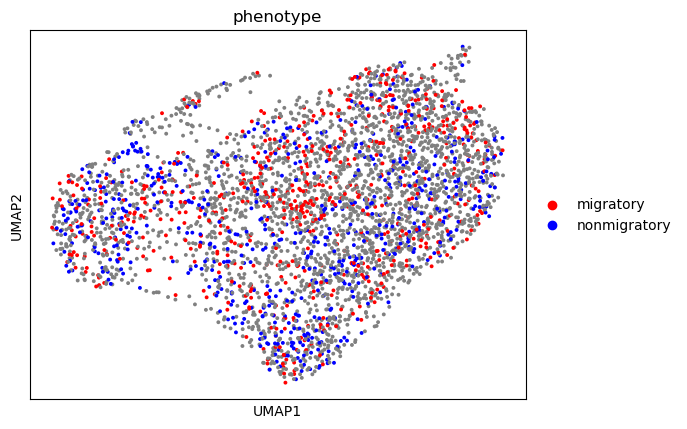

In [45]:
sc.pl.umap(adata, color='phenotype', palette=['gray', 'red', 'blue']) 